# Figure 4 · Live fast mode mapping on the instrument

Production notebook for main-text Fig. 4. Protocol on both probes: one equispaced pass,
reconstructed afterwards (rank-r Chebyshev, `activemodemap.lowrank`), scored on a separate
capture of positions the design never visited (measured within the hour).
- Soft probe: 12 positions in 13.8 min; validation 15 positions.
- Stiff probe (run R2): 8 positions in 9.6 min; validation 7 midpoints. Run R1 is in the SI.
Scores are those of notebook 04 (`results/fig4_live_fmm.csv`, Phase 2b re-score).

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
L4 = pd.read_csv(F.config.RESULTS_DIR / "fig4_live_fmm.csv")
best = L4.loc[L4.groupby("probe").nrmse.idxmin()].set_index("probe")
CASES = {"PPP-CONTAu": ("ppp_wb_fast", "ppp_wb_valid", "Soft probe", 13.8),
         "SCM-PIT-B R2": ("scmpitB_r2_wb_fast", "scmpitB_r2_wb_valid", "Stiff probe", 9.6)}
REC = {}
for name, (kd, kv, lab, tmin) in CASES.items():
    d, v = F.load(kd), F.load(kv)
    r = int(best.loc[name, "rank"])
    Zp, _ = recon.cross_capture(d.x_um, d.Z[0], v.x_um, arm="lowrank", rank=r)
    REC[name] = (d, v, Zp, r)
best[["N", "rank", "nrmse", "within_3dB", "phase_mae_deg"]].round(3)

,N,rank,nrmse,within_3dB,phase_mae_deg
probe,,,,,
PPP-CONTAu,12,8,16.941,0.978,4.101
SCM-PIT-B R1,8,5,24.888,0.940,5.158
SCM-PIT-B R2,8,5,19.055,0.989,3.368


## The figure

[PosixPath('/home/claude/work/paper_analysis/figures/Fig4_live_fmm.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/Fig4_live_fmm.pdf')]

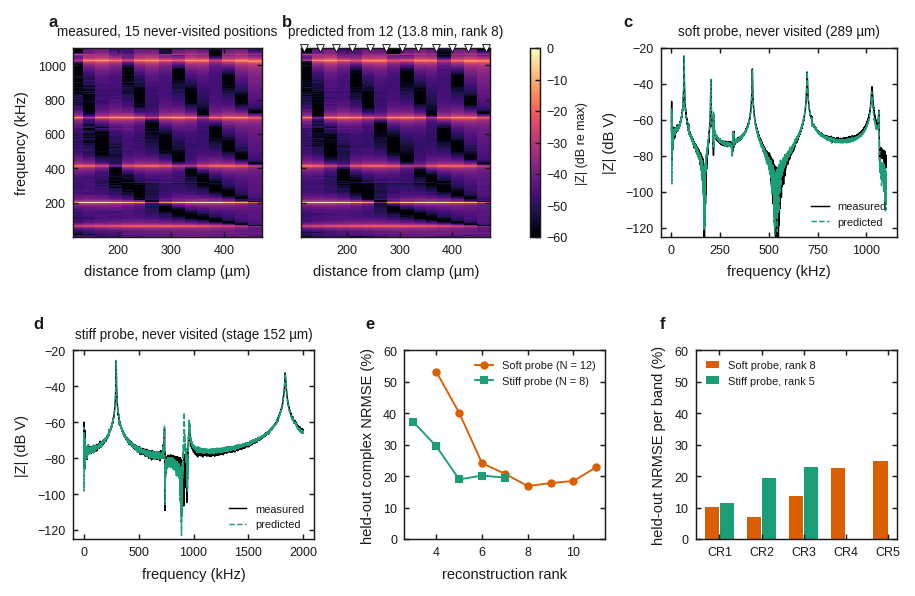

In [3]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(fp.WIDTH_IN["double"], fp.WIDTH_IN["double"] * 0.6))
gs = GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 0.05, 0.22, 1.25], hspace=0.6, wspace=0.3)
d, v, Zp, r = REC["PPP-CONTAu"]; ref = np.abs(v.Z[0]).max()
axa, axb = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
X0S = -19.0
im = fp.map_db(axa, v.x_um - X0S, v.freq_Hz, v.Z[0], ref=ref, colorbar=False)
axa.set_title("measured, 15 never-visited positions", fontsize=6.5)
fp.map_db(axb, v.x_um - X0S, v.freq_Hz, Zp, ref=ref, colorbar=False)
fp.mark_positions(axb, d.x_um - X0S)
axb.set_title(f"predicted from 12 (13.8 min, rank {r})", fontsize=6.5); axb.set_ylabel(""); axb.set_yticklabels([])
for ax in (axa, axb):
    ax.set_xlabel("distance from clamp (µm)")
cb = fig.colorbar(im, cax=fig.add_subplot(gs[0, 2])); cb.set_label("|Z| (dB re max)", fontsize=6)
fp.panel_label(axa, "a", dx=-0.08, dy=1.1); fp.panel_label(axb, "b", dx=-0.05, dy=1.1)

def spec(ax, name, j, lab):
    d, v, Zp, r = REC[name]
    ax.plot(v.freq_Hz / 1e3, 20 * np.log10(np.abs(v.Z[0, j]) + 1e-12), color=fp.C["meas"], lw=0.7, label="measured")
    ax.plot(v.freq_Hz / 1e3, 20 * np.log10(np.abs(Zp[j]) + 1e-12), "--", color=fp.C["lowrank"], lw=0.7, label="predicted")
    ax.set_ylim(-125, -20); ax.set_xlabel("frequency (kHz)"); ax.set_ylabel("|Z| (dB V)")
    ax.legend(loc="lower right", fontsize=5.3, handlelength=1.6)
    fp.panel_label(ax, lab, dx=-0.12, dy=1.1)
axc = fig.add_subplot(gs[0, 4]); j = len(REC["PPP-CONTAu"][1].x_um) // 2
spec(axc, "PPP-CONTAu", j, "c")
axc.set_title(f"soft probe, never visited ({REC['PPP-CONTAu'][1].x_um[j] - X0S:.0f} µm)", fontsize=6.5)

g2 = gs[1, :].subgridspec(1, 3, wspace=0.42, width_ratios=[1.2, 1, 1])
axd, axe, axf = (fig.add_subplot(g2[0, i]) for i in range(3))
j2 = len(REC["SCM-PIT-B R2"][1].x_um) // 2
spec(axd, "SCM-PIT-B R2", j2, "d")
axd.set_title(f"stiff probe, never visited (stage {REC['SCM-PIT-B R2'][1].x_um[j2]:.0f} µm)", fontsize=6.5)
# e  error vs rank
PC = {"PPP-CONTAu": ("Soft probe (N = 12)", "#d95f02", "o"), "SCM-PIT-B R2": ("Stiff probe (N = 8)", "#1b9e77", "s")}
for name, (lab, c, mk) in PC.items():
    q = L4[L4.probe == name]
    axe.plot(q["rank"], q.nrmse, marker=mk, color=c, mfc="w" if "R1" in name else c, ms=3, lw=0.9, label=lab)
axe.set_xlabel("reconstruction rank"); axe.set_ylabel("held-out complex NRMSE (%)"); axe.set_ylim(0, 60)
axe.legend(loc="upper right", fontsize=5.3, handlelength=1.6)
fp.panel_label(axe, "e", dx=-0.15, dy=1.1)
# f  per-mode error at the best rank
for k, (name, (lab, c, mk)) in enumerate(PC.items()):
    b = best.loc[name]
    modes = [m for m in ("CR1", "CR2", "CR3", "CR4", "CR5") if pd.notna(b.get(f"nrmse_{m}"))]
    axf.bar(np.arange(len(modes)) + (k - 0.5) * 0.36, [b[f"nrmse_{m}"] for m in modes], width=0.34, color=c,
            label=f"{lab.split(' (')[0]}, rank {int(b['rank'])}")
axf.set_xticks(range(5)); axf.set_xticklabels(["CR1", "CR2", "CR3", "CR4", "CR5"])
axf.set_ylabel("held-out NRMSE per band (%)"); axf.set_ylim(0, 60)
axf.legend(loc="upper left", fontsize=5.3, handlelength=1.2)
fp.panel_label(axf, "f", dx=-0.15, dy=1.1)
fp.save(fig, "Fig4_live_fmm")

In [4]:
results.save("fig4_main", {n: dict(rank=int(b["rank"]), nrmse=b.nrmse, within_3dB=b.within_3dB, phase_mae_deg=b.phase_mae_deg,
                                   **{k: b[k] for k in b.index if k.startswith("nrmse_CR") and pd.notna(b[k])})
                           for n, b in best.iterrows() if n in PC}, table=L4[L4.probe.isin(list(PC))])

PosixPath('/home/claude/work/paper_analysis/results/fig4_main.json')